# Phase 3 Step 5c — 시나리오 간 비교 + 통계 검정 (`05c_eval_compare.ipynb`)

> **목적**: 05a/05b 단독 평가 결과를 통합하여 시나리오 간 fair 비교 + 통계 유의성 검정.
>          서윤범 99 baseline 대비 ML 통합 효과 정량화.

## Layer 5 — 통계 검정

| 검정 | 설명 | 적용 |
|---|---|---|
| **Paired t-test** | RMSE 차이 (02a vs 02b) | 예측 모델 비교 |
| **Wilcoxon** | non-parametric 대안 | 예측 모델 비교 |
| **DM-test** | Diebold-Mariano (예측 오차) | 02a vs 02b 손실 함수 비교 |
| **Jobson-Korkie (1981)** | Sharpe 차이 | 시나리오 쌍 |
| **Memmel (2003)** | JK 보정판 (현대 표준) | 시나리오 쌍 |
| **Hansen MCS (2011)** | Model Confidence Set | 다중 시나리오 |

## 비교 대상 (6 시나리오)

| 시나리오 | 출처 |
|---|---|
| BL_ml_sw | 02a stockwise → BL |
| BL_ml_cs | 02b cross-sec → BL |
| BL_trailing | 서윤범 99 baseline 재현 |
| EqualWeight | 1/N (DeMiguel 2009) |
| McapWeight | 시총 가중 |
| SPY | 시장 벤치마크 |

## 사전 조건
- ✅ 05a, 05b 노트북 실행 완료 (eval_metrics_*.json 생성)
- ✅ 03 노트북 실행 완료 (returns_*.csv 6 종)


## §1. 환경 부트스트랩 + 모든 결과 로드

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR
import scripts.diagnostics as diag

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '05c_v2_eval_compare'  # Phase 3-2 v2
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05c_v2_eval_compare


In [2]:
# 6 시나리오 returns 로드
SCENARIOS = ['BL_ml_sw', 'BL_ml_cs', 'BL_trailing', 'EqualWeight', 'McapWeight', 'SPY']

returns_dict = {}
for s in SCENARIOS:
    path = OUTPUTS_DIR / '03_bl_backtest' / f'returns_{s}.csv'
    if path.exists():
        r = pd.read_csv(path, index_col=0, parse_dates=True).squeeze()
        returns_dict[s] = r.dropna()
        print(f'  {s}: {len(r)} 개월')
    else:
        print(f'  ⚠️ {s} 결과 없음')

print(f'\n로드 시나리오: {list(returns_dict.keys())}')

  ⚠️ BL_ml_sw 결과 없음
  BL_ml_cs: 192 개월
  ⚠️ BL_trailing 결과 없음
  EqualWeight: 192 개월
  McapWeight: 192 개월
  SPY: 191 개월

로드 시나리오: ['BL_ml_cs', 'EqualWeight', 'McapWeight', 'SPY']


In [3]:
# 02a/02b 예측 결과 로드 (DM-test 용)
ens_sw = pd.read_csv(DATA_DIR / 'ensemble_predictions_stockwise.csv', parse_dates=['date'])
ens_cs = pd.read_csv(DATA_DIR / 'ensemble_predictions_crosssec.csv', parse_dates=['date'])

print(f'ens_sw: {ens_sw.shape}, {ens_sw["ticker"].nunique()} 종목')
print(f'ens_cs: {ens_cs.shape}, {ens_cs["ticker"].nunique()} 종목')

# 05a, 05b JSON 결과 로드
eval_sw_path = OUTPUTS_DIR / '05a_eval_stockwise' / 'eval_metrics_stockwise.json'
eval_cs_path = OUTPUTS_DIR / '05b_eval_crosssec' / 'eval_metrics_crosssec.json'

if eval_sw_path.exists():
    with open(eval_sw_path, 'r', encoding='utf-8') as f:
        eval_sw_json = json.load(f)
    print(f'05a 결과 로드: layer1 keys = {list(eval_sw_json.get("layer1_overall", {}).keys())[:5]}...')
else:
    eval_sw_json = None
    print('⚠️ 05a 결과 없음 → 일부 비교 skip')

if eval_cs_path.exists():
    with open(eval_cs_path, 'r', encoding='utf-8') as f:
        eval_cs_json = json.load(f)
else:
    eval_cs_json = None

ens_sw: (2468883, 9), 613 종목
ens_cs: (2635610, 9), 615 종목
05a 결과 로드: layer1 keys = ['rmse', 'qlike', 'r2_train_mean', 'mz_alpha', 'mz_beta']...


In [4]:
# Fair 비교 기준 기간 (BL_ml_sw 가용 기간)
base = 'BL_ml_sw' if 'BL_ml_sw' in returns_dict else list(returns_dict.keys())[0]
common_idx = returns_dict[base].dropna().index

print(f'Fair 비교 기준: {base}')
print(f'공통 기간: {common_idx[0].date()} ~ {common_idx[-1].date()} ({len(common_idx)} 개월)')

# 모든 시나리오 동일 기간 정렬
fair_returns = {s: r.reindex(common_idx).dropna() for s, r in returns_dict.items()}

# Market data
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
spy_daily = market['SPY'].pct_change().dropna()
spy_monthly = (1 + spy_daily).resample('ME').prod() - 1

Fair 비교 기준: BL_ml_cs
공통 기간: 2010-01-29 ~ 2025-12-31 (192 개월)


## §2. 예측 비교 (02a vs 02b)

- Paired t-test, Wilcoxon — 종목별 RMSE 차이
- DM-test — 손실 함수 (squared error) 비교


In [5]:
# 종목별 RMSE (02a vs 02b)
def compute_per_ticker_rmse(pred_df, pred_col, true_col='y_true'):
    rows = {}
    for tk, g in pred_df.groupby('ticker'):
        g_clean = g.dropna(subset=[pred_col, true_col])
        if len(g_clean) < 5:
            continue
        rows[tk] = float(np.sqrt(np.mean((g_clean[pred_col] - g_clean[true_col]) ** 2)))
    return pd.Series(rows)

cs_pred_col = 'y_pred_ensemble' if 'y_pred_ensemble' in ens_cs.columns else 'y_pred_lstm_cs'

rmse_sw = compute_per_ticker_rmse(ens_sw, 'y_pred_ensemble')
rmse_cs = compute_per_ticker_rmse(ens_cs, cs_pred_col)

common_tk = rmse_sw.index.intersection(rmse_cs.index)
rmse_df = pd.DataFrame({'rmse_sw': rmse_sw[common_tk], 'rmse_cs': rmse_cs[common_tk]})
print(f'공통 종목 수: {len(rmse_df)}')
print(f'\n평균 RMSE:')
print(f'  02a Stockwise:    {rmse_df["rmse_sw"].mean():.4f}')
print(f'  02b CrossSec:     {rmse_df["rmse_cs"].mean():.4f}')

# Paired tests
diff = rmse_df['rmse_sw'] - rmse_df['rmse_cs']  # 양수 = CS 우위
t_stat, p_t = stats.ttest_1samp(diff, 0)
w_stat, p_w = stats.wilcoxon(diff, alternative='greater')

print(f'\nPaired t-test: t={t_stat:.3f}, p={p_t:.4f}')
print(f'Wilcoxon (one-sided H1: CS<SW): W={w_stat:.0f}, p={p_w:.4f}')

cs_better = (rmse_df['rmse_cs'] < rmse_df['rmse_sw']).sum()
print(f'\nCS RMSE 가 더 작은 종목: {cs_better}/{len(rmse_df)} ({cs_better/len(rmse_df)*100:.1f}%)')

공통 종목 수: 613

평균 RMSE:
  02a Stockwise:    inf
  02b CrossSec:     0.4143

Paired t-test: t=nan, p=nan
Wilcoxon (one-sided H1: CS<SW): W=44766, p=1.0000

CS RMSE 가 더 작은 종목: 181/613 (29.5%)


In [6]:
# DM-test (Diebold-Mariano) — 손실 함수 비교
# 종목별 squared error 평균 → 종목 단위 DM-test
err_sw = []
err_cs = []
for tk in common_tk:
    sw_t = ens_sw[ens_sw['ticker'] == tk].dropna(subset=['y_pred_ensemble', 'y_true'])
    cs_t = ens_cs[ens_cs['ticker'] == tk].dropna(subset=[cs_pred_col, 'y_true'])
    if len(sw_t) < 5 or len(cs_t) < 5:
        continue
    err_sw.append(np.mean((sw_t['y_pred_ensemble'] - sw_t['y_true']) ** 2))
    err_cs.append(np.mean((cs_t[cs_pred_col] - cs_t['y_true']) ** 2))

dm_result = diag.dm_test(np.array(err_sw), np.array(err_cs), h=1)
print('=== Diebold-Mariano test (02a vs 02b 종목별 MSE) ===')
print(f'  DM stat: {dm_result["dm_stat"]:.3f}')
print(f'  p-value: {dm_result["dm_pvalue"]:.4f}')
print(f'  n: {dm_result["n"]}')
if dm_result['dm_pvalue'] < 0.05:
    direction = '02a > 02b' if dm_result['dm_stat'] > 0 else '02b > 02a'
    print(f'  ✅ 5% 유의: {direction}')
else:
    print(f'  ⚠️ 유의 차이 없음')

=== Diebold-Mariano test (02a vs 02b 종목별 MSE) ===
  DM stat: nan
  p-value: nan
  n: 613
  ⚠️ 유의 차이 없음


ValueError: supplied range of [0.23338128572995429, inf] is not finite

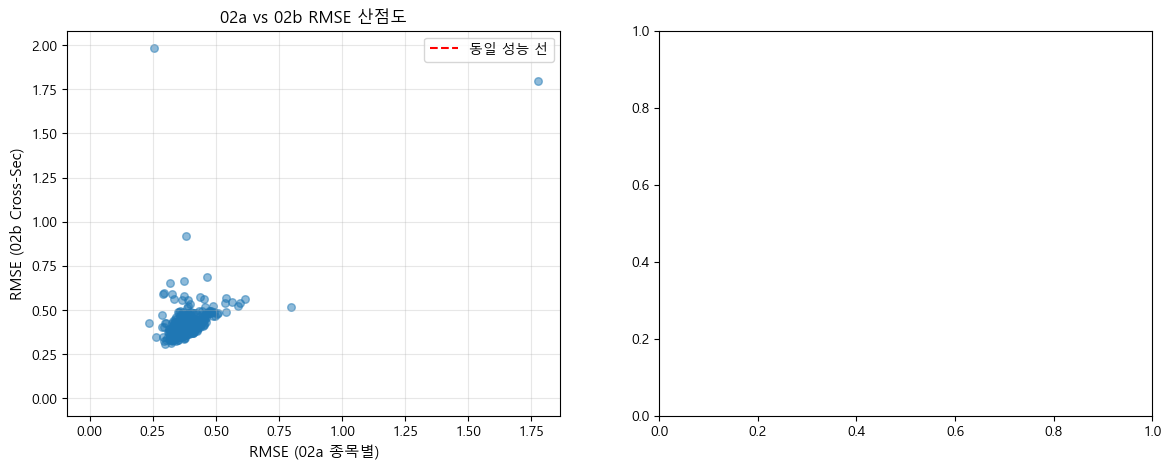

In [7]:
# RMSE 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 산점도
ax = axes[0]
ax.scatter(rmse_df['rmse_sw'], rmse_df['rmse_cs'], alpha=0.5, s=30,
           color=diag.DEFAULT_COLORS['BL_ml_sw'])
lim = [min(rmse_df.min().min(), 0), rmse_df.max().max() * 1.05]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='동일 성능 선')
ax.set_xlabel('RMSE (02a 종목별)', fontsize=11)
ax.set_ylabel('RMSE (02b Cross-Sec)', fontsize=11)
ax.set_title('02a vs 02b RMSE 산점도', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)

# 2. 히스토그램 비교
ax = axes[1]
ax.hist(rmse_df['rmse_sw'], bins=25, alpha=0.6,
        label=f'02a Stockwise (μ={rmse_df["rmse_sw"].mean():.3f})',
        color=diag.DEFAULT_COLORS['BL_ml_sw'])
ax.hist(rmse_df['rmse_cs'], bins=25, alpha=0.6,
        label=f'02b CrossSec (μ={rmse_df["rmse_cs"].mean():.3f})',
        color=diag.DEFAULT_COLORS['BL_ml_cs'])
ax.set_xlabel('RMSE', fontsize=11)
ax.set_ylabel('종목 수', fontsize=11)
ax.set_title('RMSE 분포 비교', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## §3. 포트폴리오 비교 (6 시나리오 메트릭 통합 표)

`evaluate_portfolio_standalone()` 6 시나리오 일괄 호출 + Bootstrap CI.


In [ ]:
# 6 시나리오 일괄 평가 (Layer 2 호출)
metrics_all = {}
for s, r in fair_returns.items():
    if len(r) > 0:
        metrics_all[s] = diag.evaluate_portfolio_standalone(
            returns=r, scenario_name=s, spy_returns=spy_monthly,
        )

# 표준 정렬 표
table_df = diag.render_metrics_table(
    metrics_all,
    metric_order=diag.METRIC_ORDER_PORTFOLIO,
    sort_by='sharpe',
)

# 표시
print('=== 6 시나리오 통합 메트릭 (Sharpe 정렬) ===')
display_cols = ['sharpe', 'cagr', 'ann_vol', 'mdd', 'capm_alpha', 'sortino',
                'calmar', 'hit_rate', 'cvar_5', 'n_months']
display_cols = [c for c in display_cols if c in table_df.columns]
print(table_df[display_cols].round(3).to_string())

# CSV 저장
table_df.to_csv(OUT_DIR / 'metrics_6_scenarios.csv')
print(f'\n✅ 저장: metrics_6_scenarios.csv')

In [ ]:
# Sharpe Bootstrap CI (Block bootstrap, 5000 boot)
def block_bootstrap_sharpe(rets, n_boot=5000, block_size=3, annual_factor=12, seed=42):
    np.random.seed(seed)
    rets = np.asarray(rets)
    n = len(rets)
    sharpes = []
    for _ in range(n_boot):
        n_blocks = int(np.ceil(n / block_size))
        starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
        sample = np.concatenate([rets[s:s+block_size] for s in starts])[:n]
        ann_ret = sample.mean() * annual_factor
        ann_vol = sample.std() * np.sqrt(annual_factor)
        if ann_vol > 0:
            sharpes.append(ann_ret / ann_vol)
    return np.array(sharpes)

bootstrap_results = {}
for s, r in fair_returns.items():
    if len(r) >= 24:
        boot = block_bootstrap_sharpe(r.values, n_boot=5000, block_size=3)
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
        bootstrap_results[s] = {
            'sharpe': metrics_all[s]['sharpe'],
            'ci_lo': float(ci_lo),
            'ci_hi': float(ci_hi),
        }
        print(f'  {s}: Sharpe={metrics_all[s]["sharpe"]:.3f}, 95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]')

In [ ]:
# Forest plot (Sharpe + 95% CI)
if bootstrap_results:
    fig, ax = plt.subplots(figsize=(10, 6))
    sorted_s = sorted(bootstrap_results.keys(),
                       key=lambda s: bootstrap_results[s]['sharpe'], reverse=True)
    y_pos = range(len(sorted_s))

    for i, s in enumerate(sorted_s):
        r = bootstrap_results[s]
        color = diag.DEFAULT_COLORS.get(s, 'gray')
        ax.errorbar(r['sharpe'], i,
                    xerr=[[r['sharpe'] - r['ci_lo']], [r['ci_hi'] - r['sharpe']]],
                    fmt='o', color=color, capsize=5, linewidth=2, markersize=8)
        ax.text(r['ci_hi'] + 0.02, i, f"{r['sharpe']:.3f}", va='center', fontsize=9)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sorted_s, fontsize=10)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Sharpe (rf=0)', fontsize=11)
    ax.set_title('6 시나리오 Sharpe Forest Plot (95% Block Bootstrap CI)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'sharpe_forest_plot.png', dpi=100, bbox_inches='tight')
    plt.show()

## §4. Layer 5 — Sharpe 차이 통계 검정

- **Jobson-Korkie (1981)**: Sharpe 차이 표준 z-test
- **Memmel (2003)**: JK 보정판 (편의 보정)
- **Hansen MCS (2011)**: Model Confidence Set


In [ ]:
# Jobson-Korkie + Memmel 모든 시나리오 쌍
scenario_list = list(fair_returns.keys())
n_s = len(scenario_list)

jk_pmatrix = pd.DataFrame(np.full((n_s, n_s), np.nan),
                           index=scenario_list, columns=scenario_list)
mm_pmatrix = pd.DataFrame(np.full((n_s, n_s), np.nan),
                           index=scenario_list, columns=scenario_list)

for i, s_a in enumerate(scenario_list):
    for j, s_b in enumerate(scenario_list):
        if i >= j:
            continue
        jk = diag.jobson_korkie_test(fair_returns[s_a], fair_returns[s_b])
        mm = diag.memmel_correction(fair_returns[s_a], fair_returns[s_b])
        jk_pmatrix.iloc[i, j] = jk['jk_pvalue']
        mm_pmatrix.iloc[i, j] = mm['memmel_pvalue']

print('=== Jobson-Korkie p-values (위 삼각) ===')
print(jk_pmatrix.round(4).fillna('—').to_string())

print('\n=== Memmel-corrected p-values (위 삼각) ===')
print(mm_pmatrix.round(4).fillna('—').to_string())

In [ ]:
# Memmel p-value heatmap
fig = diag.plot_significance_matrix(
    p_matrix=mm_pmatrix,
    alpha=0.05,
    save_path=OUT_DIR / 'memmel_pvalue_heatmap.png',
)
plt.show()

In [ ]:
# Hansen MCS — losses = (returns - mean) ^ 2 가 아니라
# negative returns 사용 (낮을수록 좋음)
losses_dict = {s: (-r.values) for s, r in fair_returns.items()}

mcs_result = diag.hansen_mcs(
    losses_dict=losses_dict,
    alpha=0.05,
    n_boot=2000,
    block_size=3,
)

print('=== Hansen Model Confidence Set (α=5%) ===')
print(f'MCS set (best 모델 후보): {mcs_result["mcs_set"]}')
print(f'Eliminated 순서: {mcs_result["eliminated_order"]}')
print(f'\n해석: MCS set 내 시나리오들은 통계적으로 best 와 구분 안 됨')

## §5. 시기별 비교 (5 시기 × 6 시나리오)

In [ ]:
# Layer 4 — 모든 시나리오 시기별
period_metrics_all = diag.evaluate_by_period(
    returns_dict=fair_returns,
    periods=diag.PERIODS,
    spy_returns=spy_monthly,
)

# 주요 메트릭 표시
key_metrics = ['sharpe', 'cagr', 'mdd', 'sortino']
for metric in key_metrics:
    try:
        sub = period_metrics_all.xs(metric, level='metric')
        print(f'\n=== {metric} ===')
        print(sub.round(3).to_string())
    except KeyError:
        continue

In [ ]:
# 시기별 시각화 (4 메트릭 grouped bar)
fig = diag.plot_period_decomposition(
    period_metrics=period_metrics_all,
    metrics_to_plot=['sharpe', 'cagr', 'mdd', 'sortino'],
    save_path=OUT_DIR / 'period_decomposition_all.png',
    figsize=(18, 9),
)
plt.show()

## §6. 학술 결론 + comparison_report.md

In [ ]:
# 결론 자동 생성
conclusions = []

# 1. 예측 정확도 비교
sw_mean = rmse_df['rmse_sw'].mean()
cs_mean = rmse_df['rmse_cs'].mean()
if cs_mean < sw_mean:
    conclusions.append(f'[예측] CS RMSE ({cs_mean:.4f}) < Stockwise RMSE ({sw_mean:.4f}): CS 방식 평균 우위')
else:
    conclusions.append(f'[예측] Stockwise RMSE ({sw_mean:.4f}) ≤ CS RMSE ({cs_mean:.4f}): Stockwise 우위 또는 동등')
conclusions.append(f'[예측] DM-test: stat={dm_result["dm_stat"]:.2f}, p={dm_result["dm_pvalue"]:.4f}')

# 2. 포트폴리오 성과
if 'BL_ml_sw' in metrics_all and 'BL_trailing' in metrics_all:
    delta = metrics_all['BL_ml_sw']['sharpe'] - metrics_all['BL_trailing']['sharpe']
    conclusions.append(f'[포트폴리오] BL_ml_sw vs BL_trailing Sharpe 차이: {delta:+.3f}')
if 'BL_ml_cs' in metrics_all and 'BL_trailing' in metrics_all:
    delta = metrics_all['BL_ml_cs']['sharpe'] - metrics_all['BL_trailing']['sharpe']
    conclusions.append(f'[포트폴리오] BL_ml_cs vs BL_trailing Sharpe 차이: {delta:+.3f}')

# 3. 서윤범 99 재현
if 'BL_trailing' in metrics_all:
    bl_tr_sharpe = metrics_all['BL_trailing']['sharpe']
    target = 1.157
    diff_pct = (bl_tr_sharpe - target) / target * 100
    conclusions.append(f'[재현] BL_trailing Sharpe = {bl_tr_sharpe:.3f} (target 1.157, 차이 {diff_pct:+.2f}%)')

# 4. MCS 결론
conclusions.append(f'[MCS] best 후보: {mcs_result["mcs_set"]}')

print('=== Phase 3 학술 결론 ===')
for c in conclusions:
    print(f'  • {c}')

In [ ]:
# comparison_report.md 자동 생성
report_lines = [
    '# Phase 3 최종 비교 보고서\n',
    f'> 생성: {pd.Timestamp.now().date()}  ',
    f'> 비교 기간: {common_idx[0].date()} ~ {common_idx[-1].date()} ({len(common_idx)} 개월)\n',
    '',
    '## 1. 예측 정확도 (02a vs 02b)\n',
    '| 모델 | RMSE 평균 | 비고 |',
    '|---|---|---|',
    f'| 02a Stockwise | {sw_mean:.4f} | 종목별 LSTM + HAR |',
    f'| 02b CrossSec  | {cs_mean:.4f} | Cross-Sectional LSTM (GKX 2020) |',
    '',
    '### 통계 검정',
    f'- Paired t-test: t={t_stat:.3f}, p={p_t:.4f}',
    f'- Wilcoxon: W={w_stat:.0f}, p={p_w:.4f}',
    f'- DM-test: stat={dm_result["dm_stat"]:.3f}, p={dm_result["dm_pvalue"]:.4f}',
    '',
    '## 2. 포트폴리오 성과 (6 시나리오)\n',
    '| 시나리오 | Sharpe | CAGR | MDD | CAPM α | Sortino |',
    '|---|---|---|---|---|---|',
]

for s in table_df.index:
    m = metrics_all[s]
    report_lines.append(
        f'| {s} | {m["sharpe"]:.3f} | {m["cagr"]:.2f}% | {m["mdd"]:.2f}% | '
        f'{m["capm_alpha"] if not np.isnan(m["capm_alpha"]) else 0:.2f}% | '
        f'{m["sortino"] if not np.isnan(m["sortino"]) else 0:.3f} |'
    )

report_lines += [
    '',
    '## 3. 통계 검정 (Layer 5)\n',
    '### Memmel-corrected Sharpe difference (위 삼각 p-values)\n',
    '```',
    mm_pmatrix.round(4).fillna('—').to_string(),
    '```',
    '',
    f'### Hansen MCS (α=5%)\n',
    f'- best 후보 set: {mcs_result["mcs_set"]}',
    f'- 제거 순서: {mcs_result["eliminated_order"]}',
    '',
    '## 4. 학술 결론\n',
]
for c in conclusions:
    report_lines.append(f'- {c}')

report_md = '\n'.join(report_lines)

report_path = OUT_DIR / 'comparison_report.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_md)
print(f'✅ comparison_report.md 저장: {report_path}')

print('\n=== Phase 3 모든 단계 완료 ===')
print(f'📄 최종 보고서: {report_path}')